# Example of biofilm Z-stack deconvolution and quantification

__Steps__:
1. Download zip folder for a given experiment/condition and extract the data. Convert nd2 file to single Z-stack tiff files using 'nd2_to_tiff_z-stack.py'
2. In this example, we will process data from the first Z-stack of the first frame of 'ATCC25922GFP_biofilm_rep1.zip'
3. First, we run deconvolution using Deconwolf from the command line
4. Then, we import deconvolved Z-stacks and extract fluorescence signal from GFP and SYTOX Orange, which are finally exported as dataframes

__Requirements on how to run__:
1. This notebook assumes the biofilm extracted, tiff-converted, and deconvolved file data folder, here the tiff Z-stack files for the GFP (c1) and SYTOX Orange (c2) channels, lives in the same folder as the notebook

__Code underlying data and figures__:
- Biofilm Z-stacks with strain ATCC 25922GFP
- Figures 6 and S9

## 1. Run deconvolution with Deconwolf

__Convert tiff to nd2 using command (to be run in environment with required packages, see master README file)__

```python "path to nd2_to_tiff_z-stack.py" `
""path to nd2 biofilm file e.g. ATCC25922GFP_biofilm_rep1\ATCC25922GFP_biofilm_rep1.nd2" `
-o ""path to tiff folder where to output the single frame tiff Z-stacks e.g. \ATCC25922GFP_biofilm_rep1\tiff" --z-stack```

__Generation of theoretical PSF for the three fluiorophores GFP, SYTOX Orange, EbbaBiolight 680__


```dw_bw --resxy 162.286 --resz 600 --nslice 145 --NA 0.95 --ni 1 --lambda 525 "PSF_GFP_0.6um.tiff"    # generate PSF GFP```

```dw_bw --resxy 162.286 --resz 600 --nslice 145 --NA 0.95 --ni 1 --lambda 610 "PSF_sytox_orange_0.6um.tiff"    # generate PSF SYTOX Orange```

```dw_bw --resxy 162.286 --resz 600 --nslice 145 --NA 0.95 --ni 1 --lambda 640 "PSF_EbbaBioLight680_0.6um.tiff"   # generate PSF EbbaBiolight 680```



__Command to run Deconwolf__

To be run from the directory where the tiff Z-stacks reside, as exported by 'nd2_to_tiff_z-stack.py'

Run time: 12-36 hours for a full experiment with 16 positions, 22-24 frames, 73 planes, and GPU acceleration

```
$dwExe    = "path to dw.exe"
$psfGfp   = "path to PSF_GFP_0.6um.tiff"
$psfSytox = "path to PSF_sytox_orange_0.6um.tiff"
$psfEbba = "path to PSF_EbbaBioLight680_0.6um.tiff"


$iter = 50
$useGpu = $true
$clDevice = 1
# --- RUN ---
$outDir = Join-Path (Get-Location) "dw"
New-Item -ItemType Directory -Force -Path $outDir | Out-Null
Get-ChildItem -File -Filter "*.tif" | ForEach-Object {
    $inFile = $_.FullName
    $inName = $_.Name
    $base   = $_.BaseName
    # Pick PSF by channel suffix
    
    $psf = $null
    if ($inName -match "c0\.tif$") {
       Write-Host "SKIP brightfield: $inName"
       return
    }
    elseif ($inName -match "c1\.tif$") {
        $psf = $psfGfp
       }
    elseif ($inName -match "c2\.tif$") {
        # Red channel: positions xy15-16 are EbbaBioLight680, all others are SYTOX Orange.
        if ($inName -match "xy(\d+)") {
            $xyNum = [int]$matches[1]
            if ($xyNum -ge 15 -and $xyNum -le 16) {
                $psf = $psfEbba
            }
            else {
                $psf = $psfSytox
            }
        }
        else {
            Write-Warning "c2 file has no xy index, defaulting to SYTOX: $inName"
            $psf = $psfSytox
        }
    }
    if (-not $psf) {
        Write-Warning "Skip (no c1/c2 match): $inName"
        return
    }
    # deconwolf auto-writes: dw_<inputName>.tif in the same folder as input
    $autoOut = Join-Path $_.DirectoryName ("dw_" + $inName)
    $autoLog = $autoOut + ".log.txt"
    # If we've already produced the final output, skip
    $finalOut = Join-Path $outDir ($base + "_dw.tif")
    if (Test-Path $finalOut) {
        Write-Host "SKIP (exists): $($inName) -> $(Split-Path $finalOut -Leaf)"
        return
    }
    Write-Host ("DW: {0}  (PSF: {1})" -f $inName, (Split-Path $psf -Leaf))
    # Build argument list (NO output filename argument!)
    $args = @("--iter", "$iter")

    # Build argument list
    $dwArgs = @("--iter", "$iter")

    if ($useGpu) {
        $dwArgs += "--gpu"
        $dwArgs += "--cldevice"
        $dwArgs += "$clDevice"
        $dwArgs += "--tilesize"
        $dwArgs += "1024"
    }

    $dwArgs += $inFile
    $dwArgs += $psf

    Write-Host ("CMD: `"{0}`" {1}" -f $dwExe, ($dwArgs -join " "))

    & $dwExe @dwArgs
    $exit = $LASTEXITCODE

    if ($exit -ne 0) {
        Write-Warning ("dw failed on: {0} (exit code {1})" -f $inFile, $exit)
        return
    }
    if (-not (Test-Path $autoOut)) {
        Write-Warning ("Expected output not found: {0}" -f $autoOut)
        return
    }
    # Move + rename output to dw\<input>_dw.tif
    Move-Item -Force $autoOut $finalOut
    # Move log too (if present)
    if (Test-Path $autoLog) {
        $finalLog = $finalOut + ".log.txt"
        Move-Item -Force $autoLog $finalLog
    }
    Write-Host ("   -> {0}" -f (Split-Path -Leaf $finalOut))
}
Write-Host "Done."```

__Quantify fluorescence intensity from biofilm cells (GFP) and permeabilized cells (SYTOX Orange)__

Run time: few seconds per frame, per position

Found 1 positions.
Output: I:\Science communication\Manuscripts\Papers\2026\AMP story\To_Github\Fragasso_et_al_2025\6_demos\9_ATCC25922GFP_biofilm_deconvolution_and_quantification\ATTC25922GFP_biofilm_rep1\dw\biomass_extracted_dfs

=== Processing xy01 ===


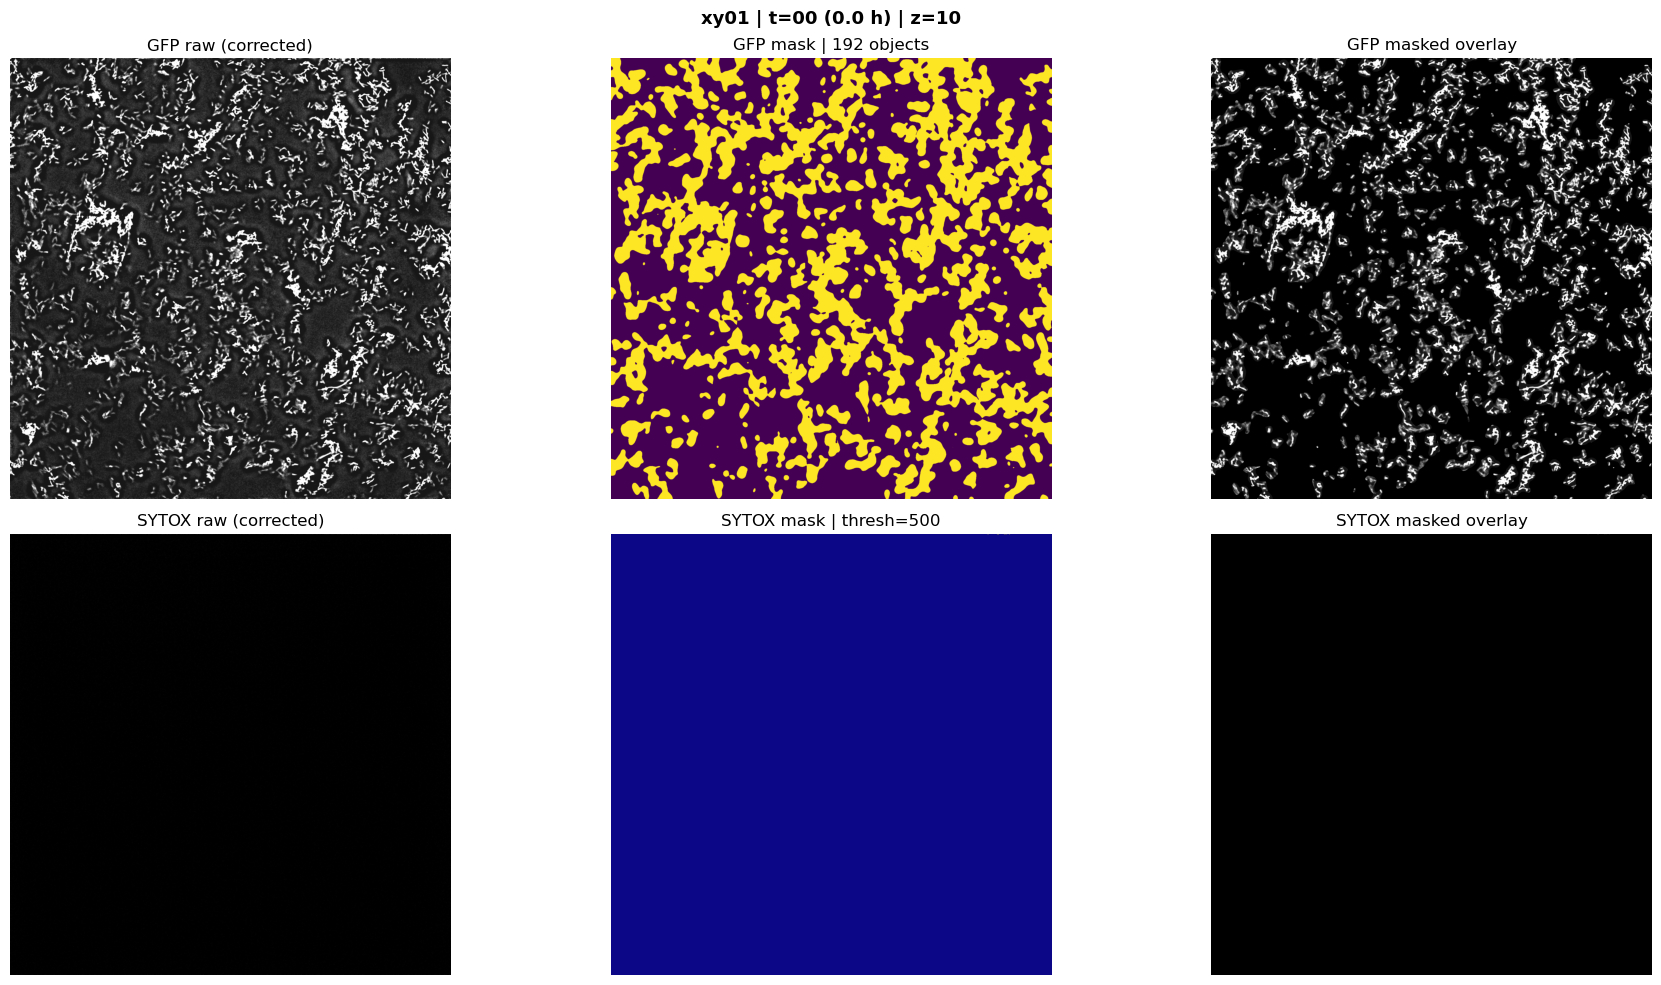

  t=00 (0.0 h) | Vol GFP: 471830.6 µm³ | Raw GFP: 4.40e+10
--> Saved: biomass_results_xy01.pkl

Done.


In [5]:
# -*- coding: utf-8 -*-
"""
Quantify GFP biomass and SYTOX Orange signal from deconvolved wide-field biofilm z-stacks.

For each microscopy position the script:
  1. Reads paired Deconwolf-deconvolved GFP (c1) and SYTOX (c2) z-stacks
  2. Rescales intensities by the Deconwolf calibration factor from the .log.txt file
  3. Truncates the z-stack to a fixed region above the glass slide
  4. Segments GFP biomass with adaptive local thresholding; SYTOX with a fixed threshold
  5. Computes per-timepoint biovolume, mean intensity, integrated signal, and raw volume signal
  6. Saves per-position results as pickle DataFrames under <dw_folder>/biomass_extracted_dfs/

Output DataFrame columns (one row per timepoint per position):
  file_base, position_id, timepoint, biomass_volume_gfp, biomass_volume_sytox,
  mean_gfp, mean_sytox, integrated_biomass_gfp, integrated_biomass_sytox,
  gfp_initial_object_count, total_raw_signal_gfp, total_raw_signal_sytox

@author: alessio fragasso
"""

import re
import tifffile as tiff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import ndimage as ndi
from skimage.morphology import remove_small_objects
from skimage.filters import threshold_local

'''Set directory'''
from pathlib import Path
target_directory = str(Path("ATCC25922GFP_biofilm_rep1/dw").resolve())

'''Parameters'''
PX_SIZE_XY = 0.162286   # µm/px (lateral)
PX_SIZE_Z  = 0.6        # µm/slice (axial)
VOXEL_VOL  = PX_SIZE_XY * PX_SIZE_XY * PX_SIZE_Z  # µm³

# z-stack truncation: skip first Z_START_INDEX slices (below glass), keep Z_SLICES_COUNT
Z_START_INDEX  = 3
Z_SLICES_COUNT = 40
Z_END_INDEX    = Z_START_INDEX + Z_SLICES_COUNT

# GFP segmentation: adaptive local threshold
GFP_SIGMA      = 10.0
GFP_BLOCK_SIZE = 61
GFP_OFFSET     = 80
GFP_FLOOR      = 300   # minimum threshold value (retains expanding biofilm edges)

# SYTOX segmentation: fixed threshold
SYTOX_SIGMA  = 1.5
SYTOX_THRESH = 500

# Minimum object size [voxels] for both channels
SAFE_MIN_SIZE_PX = 200

# Maximum timepoints to process (0-indexed; 48 = 24 h at 30-min intervals)
MAX_TIMEPOINTS = 48

# Diagnostic monitoring z-slice (raw index before truncation)
MONITOR_Z_RAW = 10


'''Helper: parse Deconwolf scaling factor from log file'''
def get_scaling_factor(tif_path):
    log_path = Path(str(tif_path) + ".log.txt")
    if not log_path.exists():
        return 1.0
    try:
        with open(log_path, 'r') as f:
            matches = re.findall(r"scaling:\s+([0-9.]+)", f.read())
            if matches:
                return float(matches[-1])
    except Exception:
        pass
    return 1.0


'''Main processing function'''
def batch_process_by_position(dw_folder_path):
    """
    Iterate over all positions found in dw_folder_path, process each timepoint,
    and save per-position result DataFrames to <dw_folder>/biomass_extracted_dfs/.
    """

    dw_folder = Path(dw_folder_path)
    output_subfolder = dw_folder / "biomass_extracted_dfs"
    output_subfolder.mkdir(exist_ok=True)

    all_c1_files = sorted(dw_folder.glob("*_t*xy*c1_dw.tif"))

    if not all_c1_files:
        print("No Deconwolf Channel 1 (*c1_dw.tif) files found.")
        return

    # Group GFP files by position
    position_bundles = {}
    for f_path in all_c1_files:
        m = re.search(r'_t(\d+)xy(\d+)c1_dw\.tif', f_path.name)
        if m:
            pos_id = f"xy{m.group(2)}"
            position_bundles.setdefault(pos_id, []).append(f_path)

    print(f"Found {len(position_bundles)} positions.")
    print(f"Output: {output_subfolder}\n")

    for pos_id, c1_files in sorted(position_bundles.items()):

        output_pkl = output_subfolder / f"biomass_results_{pos_id}.pkl"
        if output_pkl.exists():
            print(f"Skipping {pos_id} (already processed)")
            continue

        print(f"=== Processing {pos_id} ===")
        position_results = []

        for gfp_path in sorted(c1_files):

            m = re.search(r'_t(\d+)xy\d+c1_dw\.tif', gfp_path.name)
            if not m:
                continue

            raw_t   = int(m.group(1))
            timepoint = raw_t - 1   # 0-indexed: _t01 → timepoint 0

            if timepoint > MAX_TIMEPOINTS:
                print(f"  Reached time limit ({MAX_TIMEPOINTS} frames). Stopping.")
                break

            sytox_path = gfp_path.with_name(
                gfp_path.name.replace("c1_dw.tif", "c2_dw.tif")
            )
            if not sytox_path.exists():
                print(f"  Missing SYTOX file for t={raw_t}. Skipping.")
                continue

            # Read and rescale
            gfp_raw   = tiff.imread(gfp_path).astype(np.float32)
            sytox_raw = tiff.imread(sytox_path).astype(np.float32)

            sf_gfp   = get_scaling_factor(gfp_path)
            sf_sytox = get_scaling_factor(sytox_path)

            gfp_3d   = np.clip(gfp_raw   / sf_gfp,   0, 65535).astype(np.uint16)[Z_START_INDEX:Z_END_INDEX]
            sytox_3d = np.clip(sytox_raw / sf_sytox,  0, 65535).astype(np.uint16)[Z_START_INDEX:Z_END_INDEX]

            # Unmasked volume signal (backup metric)
            total_raw_gfp   = float(np.sum(gfp_3d))
            total_raw_sytox = float(np.sum(sytox_3d))

            # Smooth
            gfp_filt   = ndi.gaussian_filter(gfp_3d,   sigma=GFP_SIGMA)
            sytox_filt = ndi.gaussian_filter(sytox_3d, sigma=SYTOX_SIGMA)

            # Segment GFP: adaptive local threshold
            local_thresh = threshold_local(
                gfp_filt,
                block_size=GFP_BLOCK_SIZE,
                method='gaussian',
                offset=GFP_OFFSET,
            )
            local_thresh = np.clip(local_thresh, a_min=GFP_FLOOR, a_max=800)
            mask_gfp = remove_small_objects(
                gfp_filt >= local_thresh,
                min_size=SAFE_MIN_SIZE_PX,
            )

            # Segment SYTOX: fixed threshold
            mask_sytox = remove_small_objects(
                sytox_filt >= SYTOX_THRESH,
                min_size=SAFE_MIN_SIZE_PX,
            )

            # Label GFP objects for object count
            _, n_objects_gfp = ndi.label(mask_gfp)

            # Biovolume and mean intensity
            n_vox_gfp   = int(np.sum(mask_gfp))
            n_vox_sytox = int(np.sum(mask_sytox))

            vol_gfp   = n_vox_gfp   * VOXEL_VOL
            vol_sytox = n_vox_sytox * VOXEL_VOL

            mean_gfp   = float(np.mean(gfp_3d[mask_gfp]))     if n_vox_gfp   > 0 else 0.0
            mean_sytox = float(np.mean(sytox_3d[mask_sytox])) if n_vox_sytox > 0 else 0.0

            # Diagnostic plot at monitor z-slice
            plot_z = MONITOR_Z_RAW - Z_START_INDEX
            if plot_z < 0 or plot_z >= gfp_3d.shape[0]:
                plot_z = gfp_3d.shape[0] // 2

            fig, axes = plt.subplots(2, 3, figsize=(19, 10))
            fig.suptitle(
                f"{pos_id} | t={timepoint:02d} ({timepoint * 0.5:.1f} h) | z={plot_z + Z_START_INDEX}",
                fontsize=13, fontweight='bold',
            )

            axes[0, 0].imshow(gfp_3d[plot_z],           cmap='gray',   vmin=10,  vmax=1000)
            axes[0, 0].set_title("GFP raw (corrected)")
            axes[0, 1].imshow(mask_gfp[plot_z],          cmap='viridis')
            axes[0, 1].set_title(f"GFP mask | {n_objects_gfp} objects")
            axes[0, 2].imshow(mask_gfp[plot_z] * gfp_3d[plot_z], cmap='gray', vmin=10, vmax=1000)
            axes[0, 2].set_title("GFP masked overlay")

            axes[1, 0].imshow(sytox_3d[plot_z],          cmap='gray',   vmin=100, vmax=3000)
            axes[1, 0].set_title("SYTOX raw (corrected)")
            axes[1, 1].imshow(mask_sytox[plot_z],         cmap='plasma')
            axes[1, 1].set_title(f"SYTOX mask | thresh={SYTOX_THRESH}")
            axes[1, 2].imshow(mask_sytox[plot_z] * sytox_3d[plot_z], cmap='gray', vmin=100, vmax=3000)
            axes[1, 2].set_title("SYTOX masked overlay")

            for ax in axes.ravel():
                ax.axis('off')

            plt.tight_layout()
            plt.show()

            position_results.append({
                "file_base":               gfp_path.name.split("_t")[0],
                "position_id":             pos_id,
                "timepoint":               timepoint,
                "biomass_volume_gfp":      vol_gfp,
                "biomass_volume_sytox":    vol_sytox,
                "mean_gfp":                mean_gfp,
                "mean_sytox":              mean_sytox,
                "integrated_biomass_gfp":  mean_gfp   * vol_gfp,
                "integrated_biomass_sytox":mean_sytox * vol_sytox,
                "gfp_initial_object_count":n_objects_gfp,
                "total_raw_signal_gfp":    total_raw_gfp,
                "total_raw_signal_sytox":  total_raw_sytox,
            })

            print(
                f"  t={timepoint:02d} ({timepoint * 0.5:.1f} h) | "
                f"Vol GFP: {vol_gfp:.1f} µm³ | Raw GFP: {total_raw_gfp:.2e}"
            )

        if position_results:
            pd.DataFrame(position_results).to_pickle(output_pkl)
            print(f"--> Saved: {output_pkl.name}\n")
        else:
            print(f"--> No results for {pos_id}.\n")

    print("Done.")


'''Run'''
batch_process_by_position(target_directory)


### Plot all biofilm data, pooled from 3 independent replicates

(2127, 16) | reps: {'Rep2': 752, 'Rep1': 720, 'Rep3': 655} | positions/rep: {'Rep1': 16, 'Rep2': 16, 'Rep3': 16}


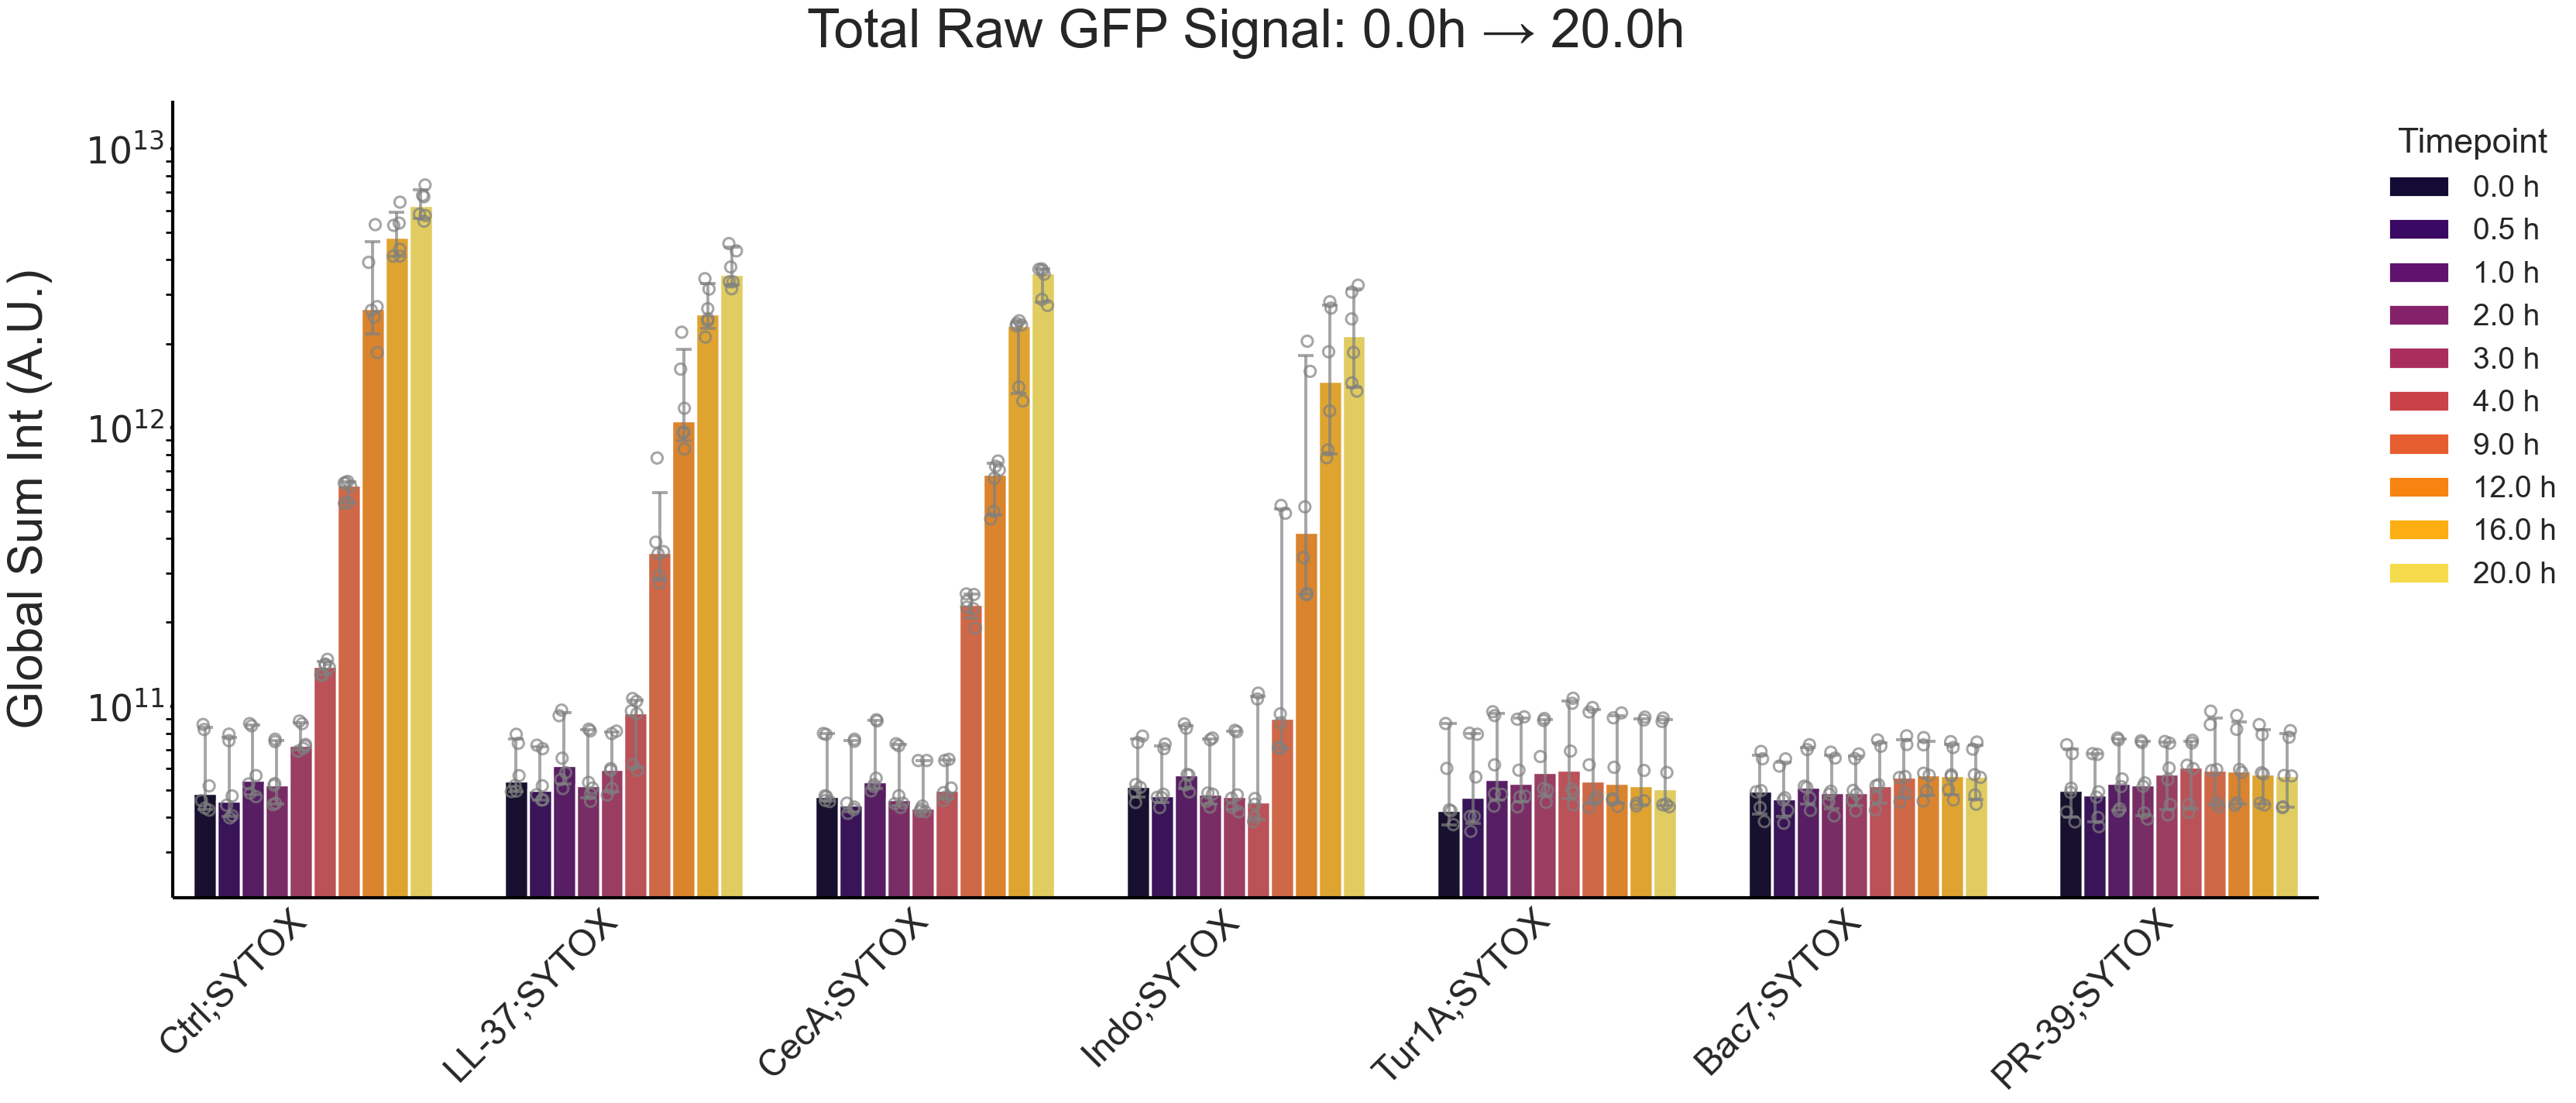

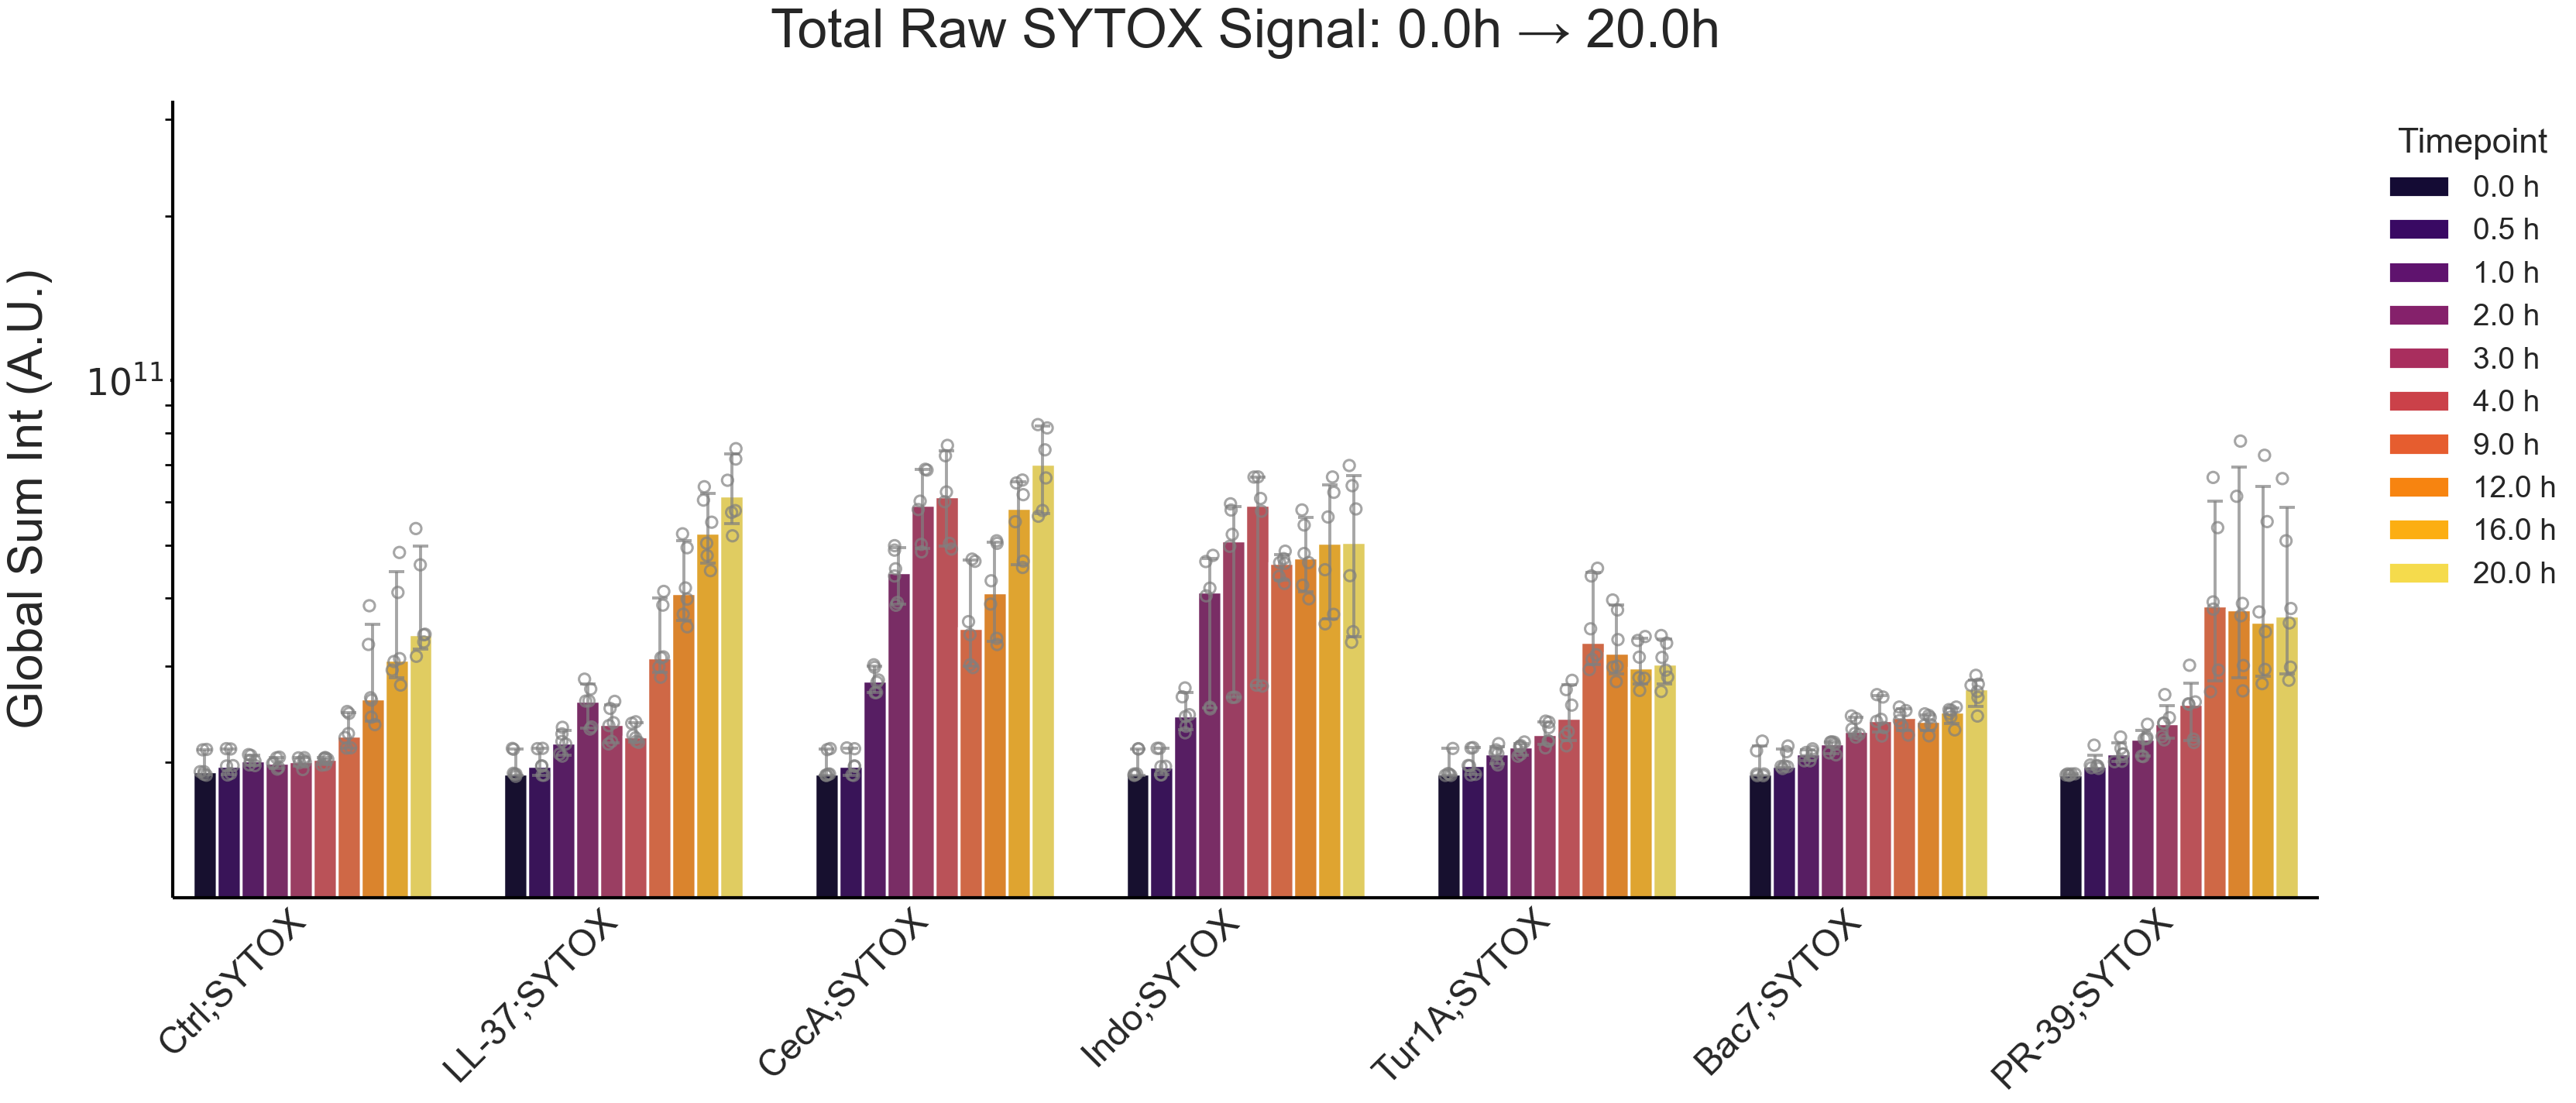

In [21]:
import glob, os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

FRAME_INTERVAL_MIN = 30
order = ["Ctrl;SYTOX", "LL-37;SYTOX", "CecA;SYTOX",
         "Indo;SYTOX", "Tur1A;SYTOX", "Bac7;SYTOX", "PR-39;SYTOX"]

mapping = {
    "xy01": "Ctrl;SYTOX",  "xy02": "Ctrl;SYTOX",
    "xy03": "LL-37;SYTOX", "xy04": "LL-37;SYTOX",
    "xy05": "CecA;SYTOX",  "xy06": "CecA;SYTOX",
    "xy07": "Indo;SYTOX",  "xy08": "Indo;SYTOX",
    "xy09": "Tur1A;SYTOX", "xy10": "Tur1A;SYTOX",
    "xy11": "Bac7;SYTOX",  "xy12": "Bac7;SYTOX",
    "xy13": "PR-39;SYTOX", "xy14": "PR-39;SYTOX",
    "xy15": "Ctrl;Ebba",   "xy16": "Ctrl;Ebba"
}
custom_palette = {
    "Ctrl;SYTOX":  "dimgray",  "Ctrl;Ebba": "black",
    "LL-37;SYTOX": "#e41a1c",  "CecA;SYTOX":  "#ff7f00",
    "Indo;SYTOX":  "#b15928",  "Bac7;SYTOX":  "#377eb8",
    "Tur1A;SYTOX": "#4daf4a",  "PR-39;SYTOX": "#984ea3",
}

# --- local rep folders (relative to this notebook) ---
experiments = {
    "Rep1": Path("biofilm_dfs_all_final/rep1"),
    "Rep2": Path("biofilm_dfs_all_final/rep2"),
    "Rep3": Path("biofilm_dfs_all_final/rep3"),
}

# --- load every per-position biomass_results pickle into one dataframe ---
df_all = pd.DataFrame()
for rep, folder in experiments.items():
    for f in sorted(folder.glob("biomass_results_*.pkl")):
        d = pd.read_pickle(f)
        d["Rep"] = rep
        df_all = pd.concat([df_all, d], ignore_index=True)

df_all["time_h"] = df_all["timepoint"] * 0.5      # 30-min frame interval
print(df_all.shape, "| reps:", df_all["Rep"].value_counts().to_dict(),
      "| positions/rep:", df_all.groupby("Rep")["position_id"].nunique().to_dict())

df = df_all.copy()

df["time_hours"] = df["timepoint"] * FRAME_INTERVAL_MIN / 60

# --- REPLICATE TAGGING ---
df["Condition"] = df["position_id"].map(mapping)
df.dropna(subset=["Condition"], inplace=True)


# =========================================================
# 6. FIGURE 4: TIMEPOINT COMPARISON BAR PLOTS — ALL METRICS
# =========================================================
target_hours = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 9.0, 12.0, 16.0, 20.0]

def snap_to_target(val, targets):
    for t in targets:
        if np.isclose(val, t, atol=0.01):
            return t
    return val

def spread_condition_groups(ax, conditions_present, condition_spacing):
    """
    Move whole condition groups apart while preserving tight hue grouping.
    Does NOT try to move Seaborn error bars.
    """
    bar_containers = [
        c for c in ax.containers
        if hasattr(c, "patches") and len(c.patches) > 0
    ]

    for container in bar_containers:
        for cond_i, patch in enumerate(container.patches):
            old_center = patch.get_x() + patch.get_width() / 2
            hue_offset = old_center - cond_i

            new_center = cond_i * condition_spacing + hue_offset
            patch.set_x(new_center - patch.get_width() / 2)

    new_xticks = np.arange(len(conditions_present)) * condition_spacing
    ax.set_xticks(new_xticks)
    ax.set_xticklabels(conditions_present, rotation=45, ha="right")

    ax.set_xlim(
        new_xticks[0] - condition_spacing * 0.45,
        new_xticks[-1] + condition_spacing * 0.45
    )

    return bar_containers


def bootstrap_ci_median(vals, n_boot=2000, ci=95, seed=1):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return np.nan, np.nan, np.nan

    med = np.median(vals)

    if len(vals) == 1:
        return med, med, med

    rng_boot = np.random.default_rng(seed)
    boots = rng_boot.choice(vals, size=(n_boot, len(vals)), replace=True)
    boot_meds = np.median(boots, axis=1)

    alpha = (100 - ci) / 2
    lo, hi = np.percentile(boot_meds, [alpha, 100 - alpha])

    return med, lo, hi

df_bars = df[df['time_hours'].apply(
    lambda x: any(np.isclose(x, h, atol=0.01) for h in target_hours))].copy()

if not df_bars.empty:
    df_bars['time_hours'] = df_bars['time_hours'].apply(
        lambda x: snap_to_target(x, target_hours))

plt.rcParams.update({
    'font.size': 32, 'axes.labelsize': 45,
    'xtick.labelsize': 34, 'ytick.labelsize': 34,
    'legend.fontsize': 28
})

bar_metrics = [
    ("total_raw_signal_gfp",      "Total Raw GFP Signal",          "Global Sum Int (A.U.)", True),
    ("total_raw_signal_sytox",    "Total Raw SYTOX Signal",         "Global Sum Int (A.U.)", True),
]

conditions_present = [c for c in order if c in df_bars["Condition"].unique()]
unique_times = sorted(df_bars["time_hours"].unique())
start_h = min(unique_times)
end_h = max(unique_times)

df_bars["time_label"] = df_bars["time_hours"].apply(lambda t: f"{float(t):.1f} h")
time_order = [f"{float(t):.1f} h" for t in unique_times]

time_colors = sns.color_palette("inferno", n_colors=len(time_order))



time_palette = {
    label: color
    for label, color in zip(time_order, time_colors)
}

legend_handles = [
    Patch(
        facecolor=time_palette[label],
        edgecolor="white",
        linewidth=2,
        label=label
    )
    for label in time_order
]


    
OVERLAY_GREY = "0.5"   
OVERLAY_ALPHA = 0.7
    

BAR_WIDTH = 2.7
CONDITION_SPACING = 3.5
POINT_JITTER_FRAC = 0.2
rng = np.random.default_rng(1)
for col, title, ylabel, log_scale in bar_metrics:
    fig_b, ax_b = plt.subplots(figsize=(34, 15))
    sns.set_style("ticks")
    plot_col = col

    if log_scale:
        df_plot = df_bars.copy()
        df_plot = df_plot[np.isfinite(df_plot[col])]
        df_plot = df_plot[df_plot[col] > 0].copy()

        if df_plot.empty:
            print(f"  Skipping {col}: no positive values for log-scale plot.")
            plt.close(fig_b)
            continue

        plot_col = f"{col}_log10"
        df_plot[plot_col] = np.log10(df_plot[col])

        y_bottom_raw = df_plot[col].min() * 0.6
        y_top_raw = df_plot[col].max() * 2.0

        y_bottom_plot = np.log10(y_bottom_raw)
        y_top_plot = np.log10(y_top_raw)

    else:
        df_plot = df_bars.copy()
        df_plot = df_plot[np.isfinite(df_plot[col])].copy()

        y_bottom_plot = None
        y_top_plot = None

    sns.barplot(
        data=df_plot,
        x="Condition",
        y=plot_col,
        hue="time_label",
        hue_order=time_order,
        order=conditions_present,
        estimator=np.median,
        errorbar=None,
        palette=time_palette,
        edgecolor="white",
        linewidth=2.5,
        width=BAR_WIDTH,
        ax=ax_b
    )

    bar_containers = spread_condition_groups(
        ax=ax_b,
        conditions_present=conditions_present,
        condition_spacing=CONDITION_SPACING
    )

    if log_scale:
        for container in bar_containers:
            for patch in container.patches:
                old_height = patch.get_height()

                if not np.isfinite(old_height):
                    patch.set_visible(False)
                    continue

                patch.set_y(y_bottom_plot)
                patch.set_height(old_height - y_bottom_plot)

    # ---------------------------------------------------------
    # Manual median bootstrap 95% CI
    # ---------------------------------------------------------
    for time_label, container in zip(time_order, bar_containers):

        for condition, patch in zip(conditions_present, container.patches):
            x_center = patch.get_x() + patch.get_width() / 2

            vals = df_bars.loc[
                (df_bars["Condition"] == condition) &
                (df_bars["time_label"] == time_label),
                col
            ].dropna().values

            vals = vals[np.isfinite(vals)]

            if log_scale:
                vals = vals[vals > 0]

            if len(vals) == 0:
                continue

            med, lo, hi = bootstrap_ci_median(
                vals,
                n_boot=2000,
                ci=95,
                seed=1
            )

            if log_scale:
                if med <= 0 or lo <= 0 or hi <= 0:
                    continue

                med_plot = np.log10(med)
                lo_plot = np.log10(lo)
                hi_plot = np.log10(hi)

                yerr = np.array([
                    [med_plot - lo_plot],
                    [hi_plot - med_plot]
                ])

                y_center = med_plot

            else:
                yerr = np.array([
                    [med - lo],
                    [hi - med]
                ])

                y_center = med

            ax_b.errorbar(
                x_center,
                y_center,
                yerr=yerr,
                fmt="none",
                ecolor=OVERLAY_GREY,
                elinewidth=2.8,
                capsize=7,
                capthick=2.8,
                alpha=OVERLAY_ALPHA,
                zorder=13,
                clip_on=True
            )


    for time_label, container in zip(time_order, bar_containers):

        for condition, patch in zip(conditions_present, container.patches):
            x_center = patch.get_x() + patch.get_width() / 2
            jitter_width = patch.get_width() * POINT_JITTER_FRAC

            vals = df_bars.loc[
                (df_bars["Condition"] == condition) &
                (df_bars["time_label"] == time_label),
                col
            ].dropna().values

            vals = vals[np.isfinite(vals)]

            if log_scale:
                vals = vals[vals > 0]

            if len(vals) == 0:
                continue

            if log_scale:
                y_vals = np.log10(vals)
            else:
                y_vals = vals

            x_vals = x_center + rng.uniform(
                -jitter_width,
                jitter_width,
                size=len(vals)
            )

            ax_b.scatter(
                x_vals,
                y_vals,
                s=105,
                marker="o",
                facecolors="none",
                edgecolors=OVERLAY_GREY,
                linewidths=2.2,
                zorder=14,
                alpha=OVERLAY_ALPHA,
                clip_on=True
            )

    if ax_b.get_legend() is not None:
        ax_b.get_legend().remove()

    if log_scale:
        ax_b.set_ylim(y_bottom_plot, y_top_plot)
        ax_b.margins(y=0)
        ax_b.autoscale(False)
    
        # Force bars to start exactly at the fake-log baseline
        for container in bar_containers:
            for patch in container.patches:
                if not patch.get_visible():
                    continue
    
                bar_top = patch.get_y() + patch.get_height()
                patch.set_y(y_bottom_plot)
                patch.set_height(bar_top - y_bottom_plot)
    
        for side in ["left", "bottom", "top", "right"]:
            ax_b.spines[side].set_visible(False)
    
        x_left, x_right = ax_b.get_xlim()
        y_range = y_top_plot - y_bottom_plot
        x_range = x_right - x_left
    
        axis_lw = 3
    
        # Main custom x-axis
        ax_b.hlines(
            y=y_bottom_plot,
            xmin=x_left,
            xmax=x_right,
            color="black",
            linewidth=axis_lw,
            clip_on=False,
            zorder=30
        )
    
        # Main custom y-axis
        ax_b.vlines(
            x=x_left,
            ymin=y_bottom_plot,
            ymax=y_top_plot,
            color="black",
            linewidth=axis_lw,
            clip_on=False,
            zorder=30
        )
    
        # ---------------------------------------------------------
        # Fake log y ticks, but ONLY within the actual axis range
        # ---------------------------------------------------------
        # ---------------------------------------------------------
        # Fake log y ticks: major + minor log ticks
        # Because this is a fake log10 axis, minor ticks must be
        # created manually at log10(2), ..., log10(9) within each decade.
        # ---------------------------------------------------------
        
        major_min = int(np.floor(y_bottom_plot))
        major_max = int(np.ceil(y_top_plot))
        
        # Major ticks: powers of 10
        major_ticks = np.arange(major_min, major_max + 1, dtype=float)
        major_ticks = major_ticks[
            (major_ticks >= y_bottom_plot) &
            (major_ticks <= y_top_plot)
        ]
        
        # Minor ticks: 2–9 within each decade
        minor_ticks = []
        
        for p in range(major_min - 1, major_max + 1):
            for m in range(2, 10):
                tick = p + np.log10(m)
                if y_bottom_plot <= tick <= y_top_plot:
                    minor_ticks.append(tick)
        
        minor_ticks = np.asarray(minor_ticks, dtype=float)
        
        # Major labels only
        ax_b.set_yticks(major_ticks)
        ax_b.set_yticklabels([fr"$10^{{{int(p)}}}$" for p in major_ticks])
    
        # ---------------------------------------------------------
        # Disable matplotlib's automatic tick marks.
        # Keep labels, but draw tick marks manually on the custom axes.
        # ---------------------------------------------------------
        ax_b.tick_params(
            axis="x",
            which="both",
            length=0,
            pad=6,
            width=0
        )
    
        ax_b.tick_params(
            axis="y",
            which="both",
            length=0,
            pad=8,
            width=0
        )
            
        # Manual x tick marks: attached to custom x-axis
        x_tick_len = 0.001 * y_range
    
        for xt in ax_b.get_xticks():
            if x_left <= xt <= x_right:
                ax_b.vlines(
                    x=xt,
                    ymin=y_bottom_plot,
                    ymax=y_bottom_plot - x_tick_len,
                    color="black",
                    linewidth=axis_lw,
                    clip_on=False,
                    zorder=31
                )
    
        # Manual y tick marks: attached to custom y-axis
        # ---------------------------------------------------------
        # Manual y tick marks: major + minor, attached to custom y-axis
        # ---------------------------------------------------------
        
        major_tick_len = 0.001 * x_range
        minor_tick_len = 0.0035 * x_range
        
        # Major ticks
        for yt in major_ticks:
            ax_b.hlines(
                y=yt,
                xmin=x_left,
                xmax=x_left - major_tick_len,
                color="black",
                linewidth=axis_lw,
                clip_on=False,
                zorder=31
            )
        
        # Minor log ticks
        for yt in minor_ticks:
            ax_b.hlines(
                y=yt,
                xmin=x_left,
                xmax=x_left - minor_tick_len,
                color="black",
                linewidth=axis_lw * 0.65,
                clip_on=False,
                zorder=31
            )
     

    ax_b.set_title(
        f"{title}: {start_h:.1f}h → {end_h:.1f}h",
        pad=50,
        fontsize=50
    )

    ax_b.set_ylabel(ylabel, labelpad=30)
    ax_b.set_xlabel("", labelpad=20)

    ax_b.legend(
        handles=legend_handles,
        title="Timepoint",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    for spine in ax_b.spines.values():
        spine.set_linewidth(3)

    plt.tight_layout()

    safe_col = col.replace("/", "_per_")
    plt.show()
